## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1. Regression predicts a continuous numeric value and classification predicts a discrete class label.

2. Confusion matrix is a table that compares predicted labels to actual labels. It helps us to understand which classes are often confused, whether the model favor a class, and where errors are concentrated.

3. Accuracy is the number of correct predictions divided by total predictions, and sometimes accuracy can be misleading in imbalanced datasets for example if a dataset has an uneven distribution of dataset (in data of either 1 or 0, 99% are 1), the model has a high accuracy in predicting 1, but it ignores the other type.

4. Root Mean Squared Error measures the average magnitude of prediction error in the same unit as the target variable, and lower RMSE means better predictive accuracy in regression.

5. Overfitting means that the model is too complex. An overfitting model has a good performance on training data but poor generalization to the test data. Underfitting means that the model is too simple. An underfitting model is highly bias and has poor performance on both training and test data.

6. When we split the data into training and testing sets, the performance of the model improves because it allow that model to evaluate the model's generalization of unseen data. For instance, if we choose k based on training performance, we risk overfitting to training noise. When evaluating accuracy or RMSE on a separate test set, we get a more accurate estimate of generalization error.

7. When the model outputs a single class label, it provides a simple and clear outcome, which is easier for comprehension, but it also introduce uncertainty that for example a prediction with 50% confidence and 99% confidence are treated the same. When the model outputs probabilities for each class, it expresses uncertainty in the prediction, because the confidence of the predictions is already included.



**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [666]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

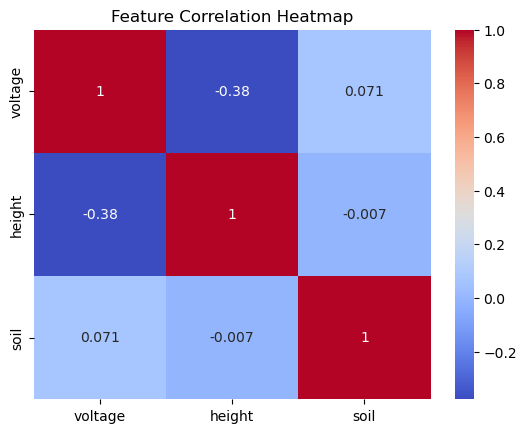

In [667]:
# 2.1

# loading dataset
lm = pd.read_csv("data/land_mines.csv")

# display features
display(lm.head())
display(lm.describe())
display(lm['mine_type'].value_counts())

# graphing
sns.heatmap(lm[["voltage","height","soil"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [668]:
# 2.2

# assign label and target
X = lm[["voltage", "height", "soil"]]
y = lm["mine_type"]

# 50/50 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train), "Test size:", len(X_test))

Train size: 169 Test size: 169


Best k: 1
Best test accuracy: 0.5088757396449705


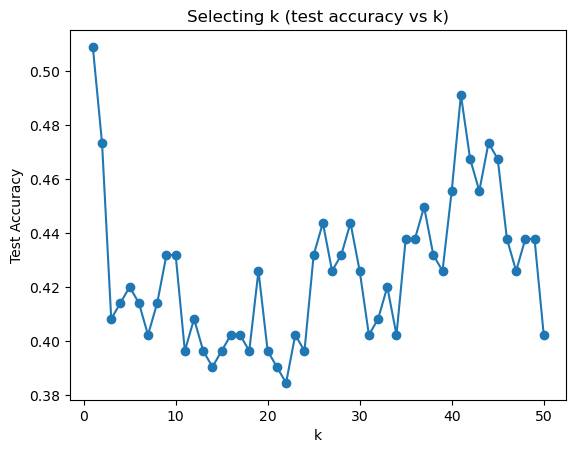

In [669]:
# 2.3

# standardize
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# find the best k value through testing possible candidates
k_values = range(1, 51)
accs = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    y_hat = model.predict(X_test_s)
    accs.append(accuracy_score(y_test, y_hat))

best_k = list(k_values)[int(np.argmax(accs))]
print("Best k:", best_k)
print("Best test accuracy:", max(accs))

# graph the trials
plt.figure()
plt.plot(list(k_values), accs, marker="o")
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Selecting k (test accuracy vs k)")
plt.show()

# produce result with best k
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_s, y_train)
y_pred = best_model.predict(X_test_s)


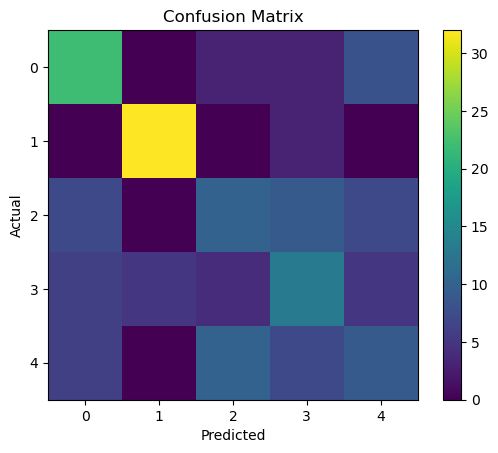

Overall test accuracy: 0.5088757396449705


In [670]:
# 2.4
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Overall test accuracy:", accuracy_score(y_test, y_pred))


# 2.5
I think sometimes the train and test do not nesscessarily need to be split as 50/50, espicailly when there is lesser data and features in the dataset

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [671]:
# 3.1
cars = pd.read_csv("data/USA_cars_datasets.csv")
cars = cars[["price", "year", "mileage"]]

display(cars.head())

# check for na
print(cars.isna().sum())

# dimension of the data after clearance
print(cars.shape)


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


price      0
year       0
mileage    0
dtype: int64
(2499, 3)


In [672]:
# 3.2
from sklearn.preprocessing import MinMaxScaler

# scaling
scaler = MinMaxScaler()

# assign label and target
X = cars[["year", "mileage"]]
y = cars["price"]

X_scaled = scaler.fit_transform(X)

In [673]:
# 3.3

# slip training and testing 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

k=3, MSE=148104157.19


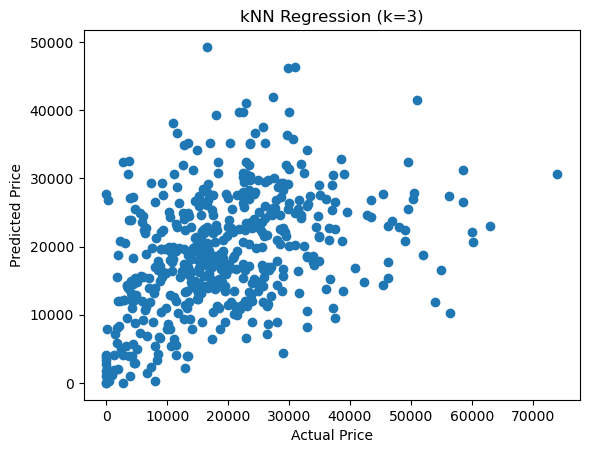

k=10, MSE=117399126.11


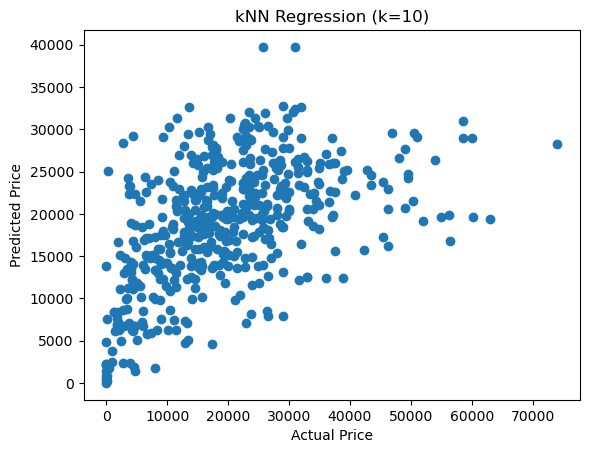

k=25, MSE=112600455.16


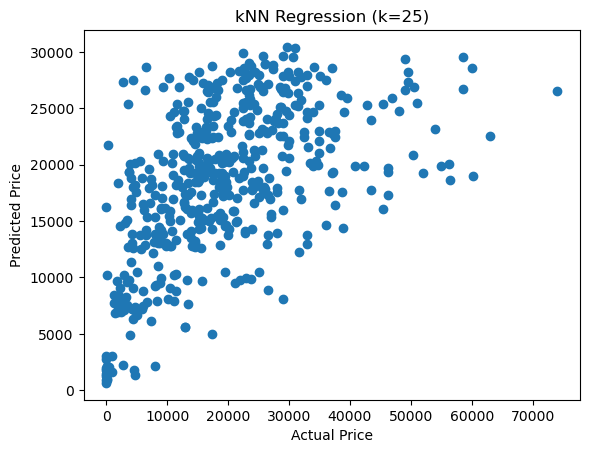

k=50, MSE=110202287.21


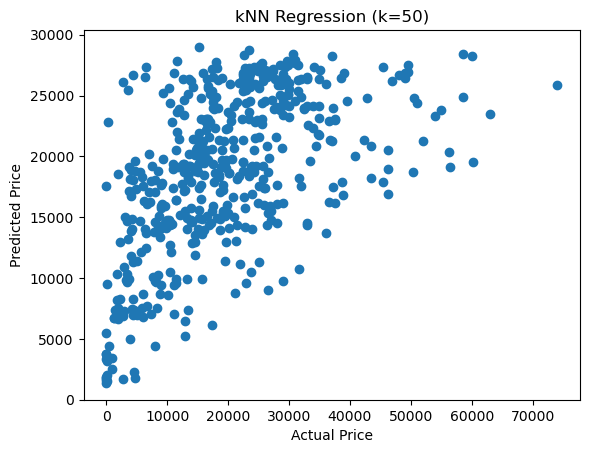

k=100, MSE=112250845.49


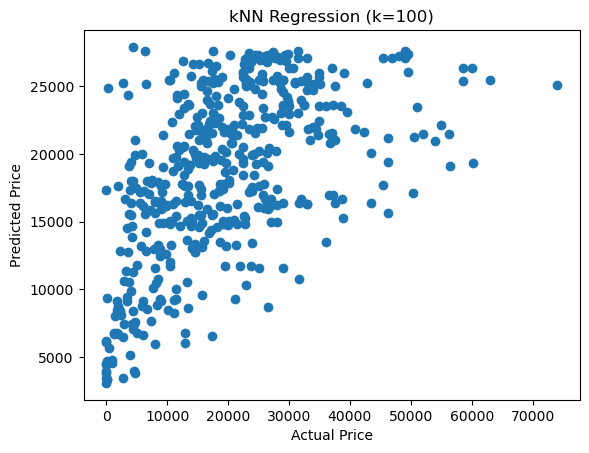

k=300, MSE=114497778.22


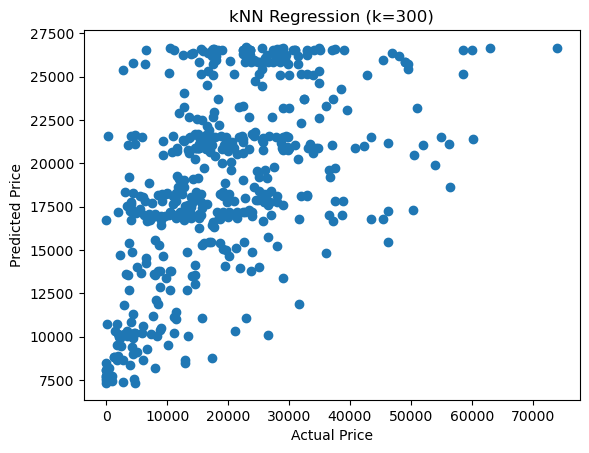

In [674]:
# 3.4
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# assign possible k value candidate
ks = [3, 10, 25, 50, 100, 300]
results = {}

# testing the possible k value candidate
for k in ks:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results[k] = mse
    
    print(f"k={k}, MSE={mse:.2f}")
    
    # graphing
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"kNN Regression (k={k})")
    plt.show()

In [675]:
# 3.5
best_k = min(results, key=results.get)
print("Optimal k:", best_k)

Optimal k: 50


# 3.6
As k increases from 3 to 50, the scatterplots became more stable and less noisy. For smaller k value, the model overfits the data, which produces variable prediction that follows the local noise resulting high result of mse. When k=50, the model achieves the best balance between bias and variance.However, as k continued to increase from 50 to 300, the model began to underfit that predictions converged toward the overall mean price, losing sensitivity to local structure and increasing MSE again.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

In [676]:
# 4.1
hfcr = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")

# investigating the dataset
display(hfcr.head())
display(hfcr.describe())
print(hfcr.isna().sum())
print(hfcr.shape)

# drop time column
hfcr = hfcr.drop(columns=["time"])
hfcr.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64
(299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


DEATH_EVENT                 1.000000
serum_creatinine            0.294278
ejection_fraction          -0.268603
age                         0.253729
serum_sodium               -0.195204
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
platelets                  -0.049139
smoking                    -0.012623
sex                        -0.004316
diabetes                   -0.001943
Name: DEATH_EVENT, dtype: float64


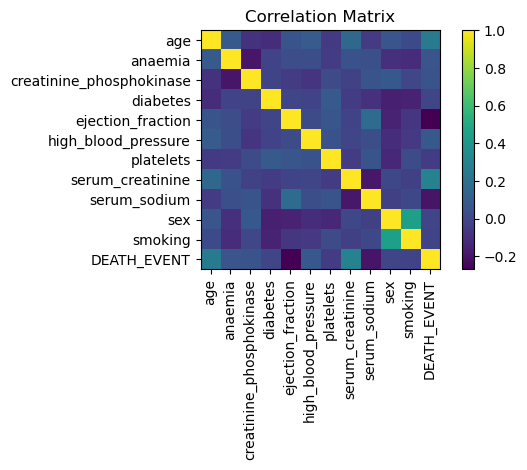

In [677]:
# 4.2
corr = hfcr.corr(numeric_only=True)
print(corr["DEATH_EVENT"].sort_values(key=lambda s: s.abs(), ascending=False))


plt.figure()
plt.imshow(corr.values)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Serum creatinine, ejection fraction, age, and serum sodium are the variables that have most strongly associated with death event.


Grouped by anaemia:
           n  death_rate  deaths
anaemia                         
0        170    0.294118      50
1        129    0.356589      46
Death rate difference (1 - 0): 0.0625

Grouped by diabetes:
            n  death_rate  deaths
diabetes                         
0         174    0.321839      56
1         125    0.320000      40
Death rate difference (1 - 0): -0.0018

Grouped by high_blood_pressure:
                       n  death_rate  deaths
high_blood_pressure                         
0                    194    0.293814      57
1                    105    0.371429      39
Death rate difference (1 - 0): 0.0776

Grouped by sex:
       n  death_rate  deaths
sex                         
0    105    0.323810      34
1    194    0.319588      62
Death rate difference (1 - 0): -0.0042

Grouped by smoking:
           n  death_rate  deaths
smoking                         
0        203    0.325123      66
1         96    0.312500      30
Death rate difference (1 - 0): -0.01

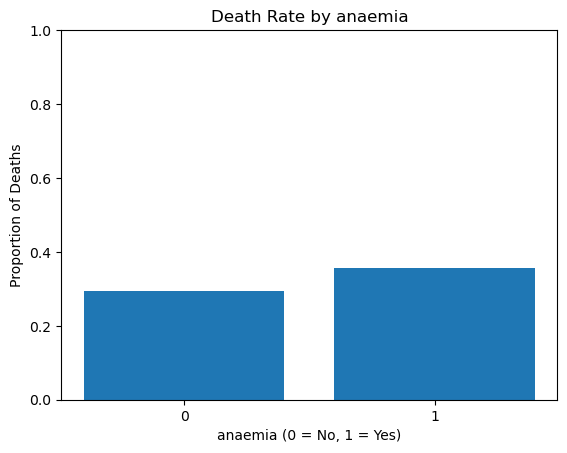

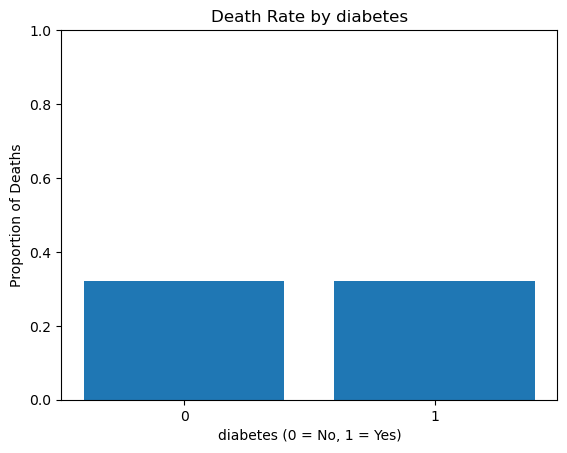

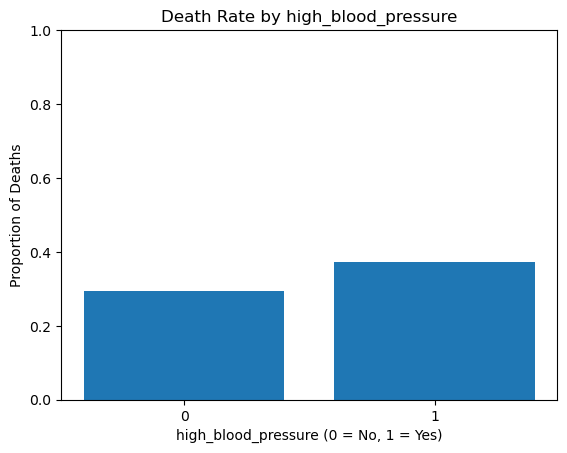

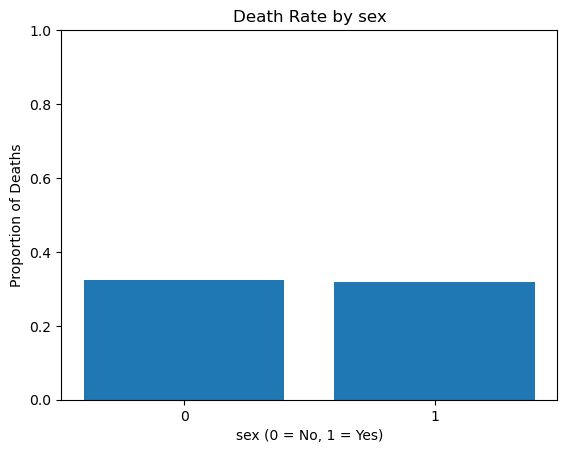

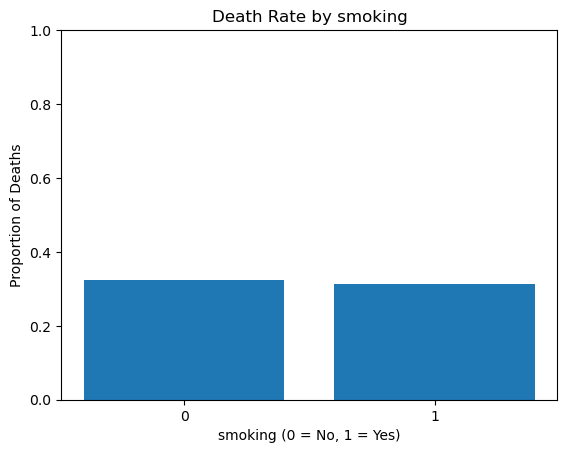

In [678]:
# 4.3
dummy_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

summary_tables = {}
for v in dummy_vars:
    tbl = hfcr.groupby(v)["DEATH_EVENT"].agg(
        n="count",
        death_rate="mean",
        deaths="sum"
    )
    summary_tables[v] = tbl
    print(f"\nGrouped by {v}:")
    print(tbl)
    
    # compare death_rate at 1 vs 0 if both exist
    if 0 in tbl.index and 1 in tbl.index:
        diff = tbl.loc[1, "death_rate"] - tbl.loc[0, "death_rate"]
        print(f"Death rate difference (1 - 0): {diff:.4f}")

dummy_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

for v in dummy_vars:
    grouped = hfcr.groupby(v)["DEATH_EVENT"].mean()
    
    plt.figure()
    plt.bar(grouped.index.astype(str), grouped.values)
    plt.xlabel(f"{v} (0 = No, 1 = Yes)")
    plt.ylabel("Proportion of Deaths")
    plt.title(f"Death Rate by {v}")
    plt.ylim(0, 1)
    plt.show()

The variables that have death rate (1) greater than death rate (0) are anaemia and high blood pressure.

In [679]:
# 4.4
features = ["serum_creatinine", "ejection_fraction", "age", "serum_sodium"]

X = hfcr[features].copy()
y = hfcr["DEATH_EVENT"].copy()

print("X shape:", X.shape, "y shape:", y.shape)
print("Features used:", features)

X shape: (299, 4) y shape: (299,)
Features used: ['serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium']


In [680]:
# 4.5
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [681]:
# 4.6
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

     k       mse      rmse
31  32  0.171566  0.414205
27  28  0.171875  0.414578
24  25  0.171920  0.414632
26  27  0.171948  0.414666
23  24  0.172222  0.414997
28  29  0.172810  0.415704
8    9  0.172840  0.415740
9   10  0.173000  0.415933
32  33  0.173079  0.416028
25  26  0.173151  0.416114


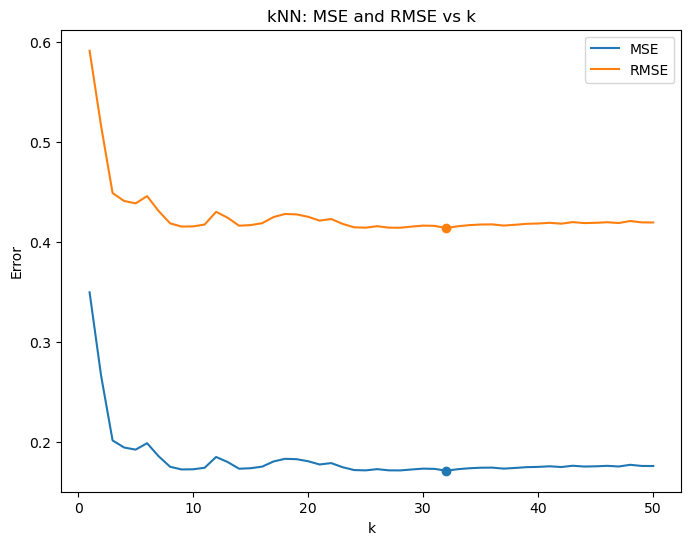

In [682]:
# 4.7
k_grid = list(range(1, 51))  #

results = []
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    results.append((k, mse, rmse))

res_df = pd.DataFrame(results, columns=["k", "mse", "rmse"]).sort_values("mse")
print(res_df.head(10))

best_k = int(res_df.iloc[0]["k"])
best_mse = float(res_df.iloc[0]["mse"])
best_rmse = float(res_df.iloc[0]["rmse"])

ks = [r[0] for r in results]
mses = [r[1] for r in results]
rmses = [r[2] for r in results]

plt.figure(figsize=(8,6))

plt.plot(ks, mses, label="MSE")
plt.plot(ks, rmses, label="RMSE")

plt.scatter(best_k, best_mse)
plt.scatter(best_k, best_rmse)

plt.xlabel("k")
plt.ylabel("Error")
plt.title("kNN: MSE and RMSE vs k")
plt.legend()

plt.show()

     k       mse      rmse
28  29  0.199802  0.446992
31  32  0.200439  0.447705
20  21  0.201361  0.448732
30  31  0.201370  0.448743
33  34  0.201471  0.448855
26  27  0.202469  0.449966
32  33  0.202632  0.450147
22  23  0.202678  0.450198
29  30  0.202852  0.450391
27  28  0.202955  0.450505


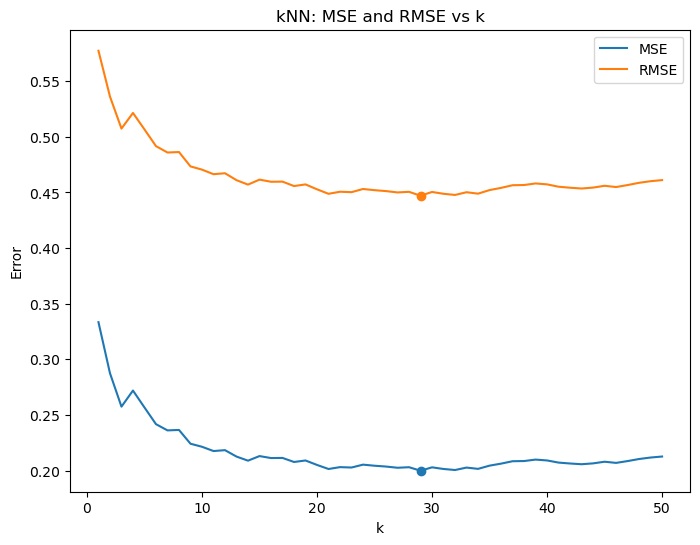

In [683]:
# 4.8

# select features
features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets','serum_creatinine', 'serum_sodium', 'sex', 'smoking']

X = hfcr[features].copy()
y = hfcr["DEATH_EVENT"].copy()

# scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# find k
k_grid = list(range(1, 51))  #

results = []
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    results.append((k, mse, rmse))

res_df = pd.DataFrame(results, columns=["k", "mse", "rmse"]).sort_values("mse")
print(res_df.head(10))

best_k = int(res_df.iloc[0]["k"])
best_mse = float(res_df.iloc[0]["mse"])
best_rmse = float(res_df.iloc[0]["rmse"])

ks = [r[0] for r in results]
mses = [r[1] for r in results]
rmses = [r[2] for r in results]

plt.figure(figsize=(8,6))

plt.plot(ks, mses, label="MSE")
plt.plot(ks, rmses, label="RMSE")

plt.scatter(best_k, best_mse)
plt.scatter(best_k, best_rmse)

plt.xlabel("k")
plt.ylabel("Error")
plt.title("kNN: MSE and RMSE vs k")
plt.legend()

plt.show()

The reduced model performs better with a lower RMSE (around 0.414) compared to the all-variable model (0.447) so so it has the lower Mean Squared Error. In practice, I would prefer the reduced model, since adding more variables increased error.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

In [684]:
# 5.1
animals = pd.read_csv("data/zoo.csv")

display(animals.head())
print("Shape: ", animals.shape)
print(animals.dtypes)

# what appear in each class
for c in sorted(animals["class"].unique()):
    animals_in_class = animals.loc[animals["class"] == c, "animal"].tolist()
    print(f"Class {c} (n={len(animals_in_class)}):")
    print(animals_in_class)

# class size
class_counts = animals["class"].value_counts().sort_index()
print("Class counts:", class_counts)

# how much variation
feature_cols = [c for c in animals.columns if c not in ["class", "animal"]]
summary = animals[feature_cols].agg(["mean", "std"]).T
print(summary.sort_values("std", ascending=False))

# which variable best predict which class
class_feature_means = animals.groupby("class")[feature_cols].mean()
print(class_feature_means)


,animal,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


Shape:  (101, 18)
animal      object
hair         int64
feathers     int64
eggs         int64
milk         int64
airborne     int64
aquatic      int64
predator     int64
toothed      int64
backbone     int64
breathes     int64
venomous     int64
fins         int64
legs         int64
tail         int64
domestic     int64
catsize      int64
class        int64
dtype: object
Class 1 (n=41):
['aardvark', 'antelope', 'bear', 'boar', 'buffalo', 'calf', 'cavy', 'cheetah', 'deer', 'dolphin', 'elephant', 'fruitbat', 'giraffe', 'girl', 'goat', 'gorilla', 'hamster', 'hare', 'leopard', 'lion', 'lynx', 'mink', 'mole', 'mongoose', 'opossum', 'oryx', 'platypus', 'polecat', 'pony', 'porpoise', 'puma', 'pussycat', 'raccoon', 'reindeer', 'seal', 'sealion', 'squirrel', 'vampire', 'vole', 'wallaby', 'wolf']
Class 2 (n=20):
['chicken', 'crow', 'dove', 'duck', 'flamingo', 'gull', 'hawk', 'kiwi', 'lark', 'ostrich', 'parakeet', 'penguin', 'pheasant', 'rhea', 'skimmer', 'skua', 'sparrow', 'swan', 'vulture', 'wr

In [685]:
# 5.2

# selecting features
feature_cols = [c for c in animals.columns if c not in ["class", "animal"]]

# set label and target
X = animals[feature_cols]
y = animals["class"]

# 50/50 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

print("Train class counts: ", y_train.value_counts().sort_index())
print("Test class counts: ", y_test.value_counts().sort_index())

Train class counts:  class
1    20
2    10
3     3
4     6
5     2
6     4
7     5
Name: count, dtype: int64
Test class counts:  class
1    21
2    10
3     2
4     7
5     2
6     4
7     5
Name: count, dtype: int64


k= 1, test accuracy=0.961
k= 2, test accuracy=0.961
k= 3, test accuracy=0.961
k= 4, test accuracy=0.902
k= 5, test accuracy=0.922
k= 6, test accuracy=0.922
k= 7, test accuracy=0.882
k= 8, test accuracy=0.882
k= 9, test accuracy=0.882
k=10, test accuracy=0.882
k=11, test accuracy=0.922
k=12, test accuracy=0.922
k=13, test accuracy=0.882
k=14, test accuracy=0.843
k=15, test accuracy=0.843
k=16, test accuracy=0.824
k=17, test accuracy=0.804
k=18, test accuracy=0.725
k=19, test accuracy=0.725
k=20, test accuracy=0.706
k=21, test accuracy=0.706
k=22, test accuracy=0.706
k=23, test accuracy=0.667
k=24, test accuracy=0.667
k=25, test accuracy=0.569
k=26, test accuracy=0.569
k=27, test accuracy=0.569
k=28, test accuracy=0.569
k=29, test accuracy=0.549
k=30, test accuracy=0.529
k=31, test accuracy=0.490
k=32, test accuracy=0.490
k=33, test accuracy=0.451
k=34, test accuracy=0.451
k=35, test accuracy=0.451
k=36, test accuracy=0.431
k=37, test accuracy=0.412
k=38, test accuracy=0.412
k=39, test a

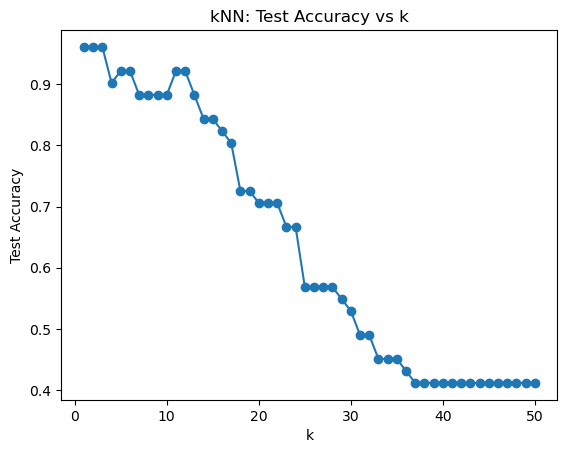

In [686]:
# 5.3

# standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# selecting the best k value
k_values = list(range(1, 51, 1)) 
accs = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    accs.append(acc)
    print(f"k={k:>2}, test accuracy={acc:.3f}")

best_idx = int(np.argmax(accs))
best_k = k_values[best_idx]
best_acc = accs[best_idx]

print("\nBest k:", best_k)
print("Best test accuracy:", best_acc)

# Optional simple plot
plt.figure()
plt.plot(k_values, accs, marker="o")
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("kNN: Test Accuracy vs k")
plt.show()

I selected the number of neighbors k by training the models for a list of k values. I look for the k value that produced the highest test accuracy.

Test accuracy: 0.9607843137254902


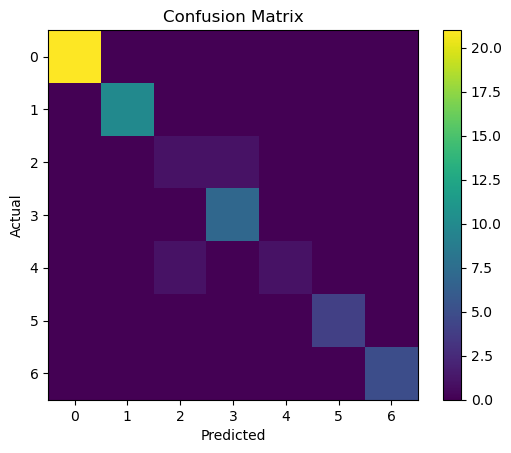

In [687]:
# 5.4

# use the best k
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train_scaled, y_train)

# predict on test set
y_pred = model.predict(X_test_scaled)

# find accuracy
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)

# build confusion matrix (cm)
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


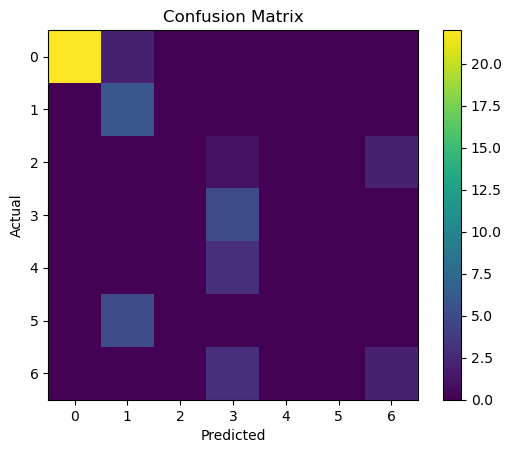

Test Accuracy:  0.6862745098039216
Classes in model: [1 2 3 4 5 6 7]
First few probability rows:
 [[1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]]


In [688]:
# 5.5

# using only 3 features
small_features = ["milk", "aquatic", "airborne"]

X_small = animals[small_features]
y = animals["class"]

# 50/50 split
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y, test_size=0.5, random_state=42
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train model using k = 1
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train_scaled, y_train)

# predict
y_pred = model.predict(X_test_scaled)

# cm and accuracy
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Test Accuracy: ", accuracy_score(y_test, y_pred))

# probability
proba = model.predict_proba(X_test_scaled)
print("Classes in model:", model.classes_)
print("First few probability rows:\n", proba[:5])

The accuracy drops from 96% to 69% with only using features milk, aquatic, and airborne. All classes appear in model.classes but in practice many prediction centered in just a few class (1). The probability output [1, 0, 0, 0 ,0, 0, 0] suggests that nearest neighbor belongs to class q so that the prediction is fully class 1 which means no uncertainty. The confusion matrix shows that reducing the amount of feature set to only 3 binary variable significant limits the model's ability to distinguish between classes. There are only 8 possible combination for those 3 binary features, which means that a lot of animal shares these features. Since k-NN cannot separate them in feature space and assigns them to the most common nearby class, the accuracy is greatly reduced.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [689]:
# 6.1

# load dataset
bnb = pd.read_csv("data/airbnb_hw.csv")
bnb = bnb.loc[:, ["Review Scores Rating", "Price", "Beds"]]

# describe the dataset
display(bnb.head())
display(bnb.dtypes)
print("Shape:", bnb.shape)

# convert price to numeric
bnb["Price"] = (bnb["Price"].astype(str).str.replace(",", "", regex=False))
display(bnb.dtypes)

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0


Review Scores Rating    float64
Price                    object
Beds                    float64
dtype: object

Shape: (30478, 3)


Review Scores Rating    float64
Price                    object
Beds                    float64
dtype: object

In [690]:
# 6.2

# rows with missing review scores
bnb_missing = bnb.loc[bnb["Review Scores Rating"].isnull()]

In [691]:
# 6.3

# drop row with NA from bn dataset
bnb_observed = bnb.dropna(axis=0, how='any')

In [692]:
# 6.4

# x and y from complete cases
X = bnb_observed[["Price", "Beds"]]
y = bnb_observed["Review Scores Rating"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try k values and compute SSE
k_values = [1, 3, 5, 7, 9, 15, 25, 50]
sse_list = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    sse = np.sum((y_test - pred) ** 2)
    sse_list.append(sse)
    print(f"k={k:>3}, SSE={sse:.2f}")

# choose best k with min SSE
best_idx = int(np.argmin(sse_list))
best_k = k_values[best_idx]
print("\nBest k:", best_k, "with SSE:", sse_list[best_idx])

k=  1, SSE=682384.00
k=  3, SSE=483563.00
k=  5, SSE=390321.96
k=  7, SSE=373400.59
k=  9, SSE=352626.41
k= 15, SSE=336957.61
k= 25, SSE=326118.23
k= 50, SSE=321369.74

Best k: 50 with SSE: 321369.74


In [693]:
# 6.5

# scale features 
X_all = bnb_observed[["Price", "Beds"]]
y_all = bnb_observed["Review Scores Rating"]

scaler_final = StandardScaler()
X_all_scaled = scaler_final.fit_transform(X_all)

final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_all_scaled, y_all)

# predict for missing rows
bnb_missing_pred = bnb_missing.dropna(subset=["Price", "Beds"]).copy()

X_missing = bnb_missing_pred[["Price", "Beds"]]
X_missing_scaled = scaler_final.transform(X_missing)

pred_missing_ratings = final_model.predict(X_missing_scaled)

# store predictions
bnb_missing_pred["Predicted Rating"] = pred_missing_ratings
print(bnb_missing_pred.head())


    Review Scores Rating Price  Beds  Predicted Rating
0                    NaN   145   1.0             94.60
1                    NaN    37   1.0             89.66
2                    NaN    28   1.0             84.70
3                    NaN   199   3.0             88.10
13                   NaN    68   1.0             91.04


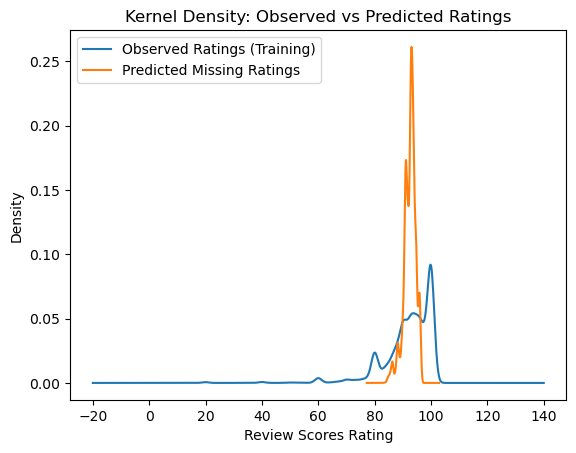

In [694]:
# 6.7

# kde of observed rating
bnb_observed["Review Scores Rating"].plot(
    kind="kde",
    label="Observed Ratings (Training)"
)

# kde of predicted missing ratings
bnb_missing_pred["Predicted Rating"].plot(
    kind="kde",
    label="Predicted Missing Ratings"
)

plt.xlabel("Review Scores Rating")
plt.title("Kernel Density: Observed vs Predicted Ratings")
plt.legend()
plt.show()

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)